In [49]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time

In [50]:
# Your TMDb API key
API_KEY = "3946df79b05d1ff469d9038d401ac1c2"

# Base URL for Top Rated Movies
BASE_URL = "https://api.themoviedb.org/3/movie/top_rated"


In [3]:
# Columns for the DataFrame
columns = [
    'id', 'title', 'original_title', 'release_date', 'vote_average', 
    'vote_count', 'popularity', 'overview', 'original_language'
]

# List to store all movies
all_movies = []


In [4]:
# TMDb API returns 20 results per page, so 30 pages for ~600 movies
for page in range(1, 31):
    params = {
        "api_key": API_KEY,
        "language": "en-US",
        "page": page
    }
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    for movie in data['results']:
        all_movies.append([
            movie.get('id'),
            movie.get('title'),
            movie.get('original_title'),
            movie.get('release_date'),
            movie.get('vote_average'),
            movie.get('vote_count'),
            movie.get('popularity'),
            movie.get('overview'),
            movie.get('original_language')
        ])


In [5]:
# Create DataFrame
df = pd.DataFrame(all_movies, columns=columns)

# Check shape
print(df.shape)  # Should be approximately (600, 9)


(600, 9)


In [6]:
# Preview DataFrame
df.head()


,id,title,original_title,release_date,vote_average,vote_count,popularity,overview,original_language
0,278,The Shawshank Redemption,The Shawshank Redemption,1994-09-23,8.711,29141,31.3451,Imprisoned in the 1940s for the double murder ...,en
1,238,The Godfather,The Godfather,1972-03-14,8.700,22013,27.6113,"Spanning the years 1945 to 1955, a chronicle o...",en
2,240,The Godfather Part II,The Godfather Part II,1974-12-20,8.571,13301,13.4407,In the continuing saga of the Corleone crime f...,en
3,424,Schindler's List,Schindler's List,1993-12-15,8.566,16826,11.7155,The true story of how businessman Oskar Schind...,en
4,389,12 Angry Men,12 Angry Men,1957-04-10,8.548,9498,9.3119,The defense and the prosecution have rested an...,en


In [7]:
df.isnull().sum()

id                   0
title                0
original_title       0
release_date         0
vote_average         0
vote_count           0
popularity           0
overview             0
original_language    0
dtype: int64

In [9]:
df.describe()

,id,vote_average,vote_count,popularity
count,6.000000e+02,600.000000,600.000000,600.000000
mean,2.291694e+05,8.033947,5423.045000,9.181841
std,3.160275e+05,0.185521,7160.076852,13.706668
min,1.100000e+01,7.800000,301.000000,0.006300
25%,9.107500e+02,7.896000,725.750000,3.503250
50%,2.530050e+04,8.000000,1963.000000,5.518100
75%,4.456130e+05,8.145500,7856.000000,9.345075
max,1.426776e+06,8.711000,38159.000000,147.005900


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 600 non-null    int64  
 1   title              600 non-null    object 
 2   original_title     600 non-null    object 
 3   release_date       600 non-null    object 
 4   vote_average       600 non-null    float64
 5   vote_count         600 non-null    int64  
 6   popularity         600 non-null    float64
 7   overview           600 non-null    object 
 8   original_language  600 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 42.3+ KB


In [12]:

duplicate_rows = df.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())


Number of duplicate rows: 0


In [13]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Convert vote_average, vote_count, popularity to numeric (if not already)
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['vote_count'] = pd.to_numeric(df['vote_count'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')



In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 600 non-null    int64         
 1   title              600 non-null    object        
 2   original_title     600 non-null    object        
 3   release_date       600 non-null    datetime64[ns]
 4   vote_average       600 non-null    float64       
 5   vote_count         600 non-null    int64         
 6   popularity         600 non-null    float64       
 7   overview           600 non-null    object        
 8   original_language  600 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 42.3+ KB


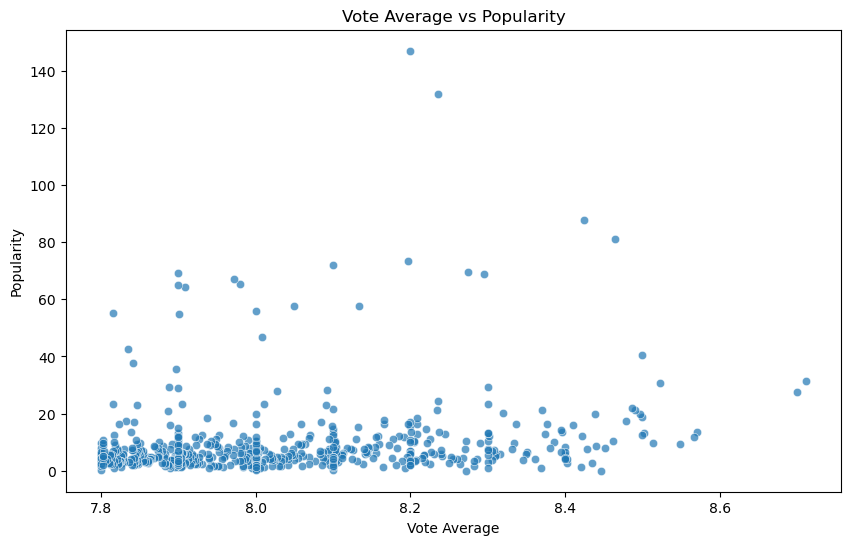

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='vote_average', y='popularity', data=df, alpha=0.7)
plt.title("Vote Average vs Popularity")
plt.xlabel("Vote Average")
plt.ylabel("Popularity")
plt.show()


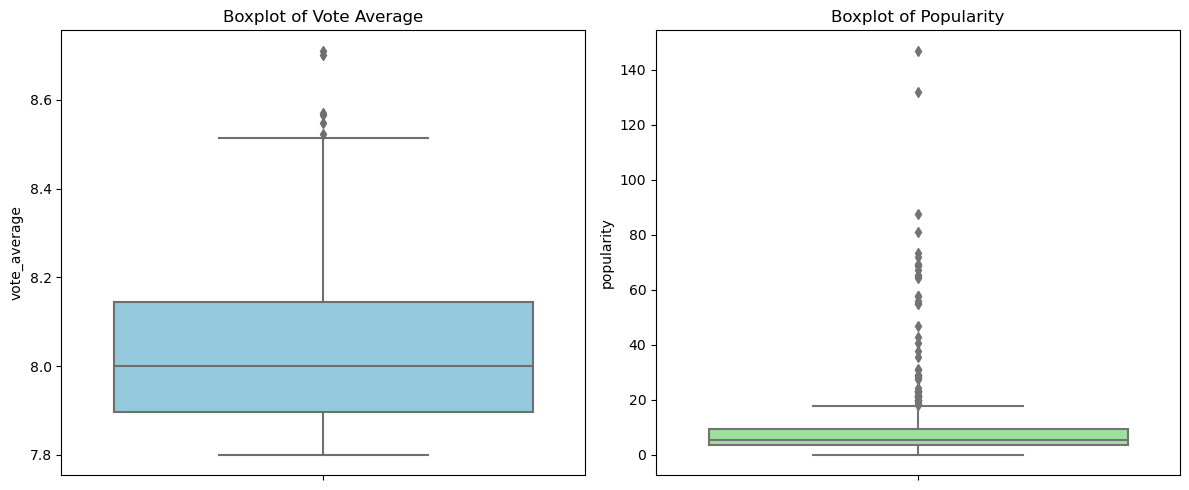

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Boxplot for Vote Average
plt.subplot(1, 2, 1)
sns.boxplot(y=df['vote_average'], color='skyblue')
plt.title("Boxplot of Vote Average")

# Boxplot for Popularity
plt.subplot(1, 2, 2)
sns.boxplot(y=df['popularity'], color='lightgreen')
plt.title("Boxplot of Popularity")

plt.tight_layout()
plt.show()


Top Movies vs Popularity
Insight: we can spot movies that are very popular but low-rated vs high-rated but less popular.

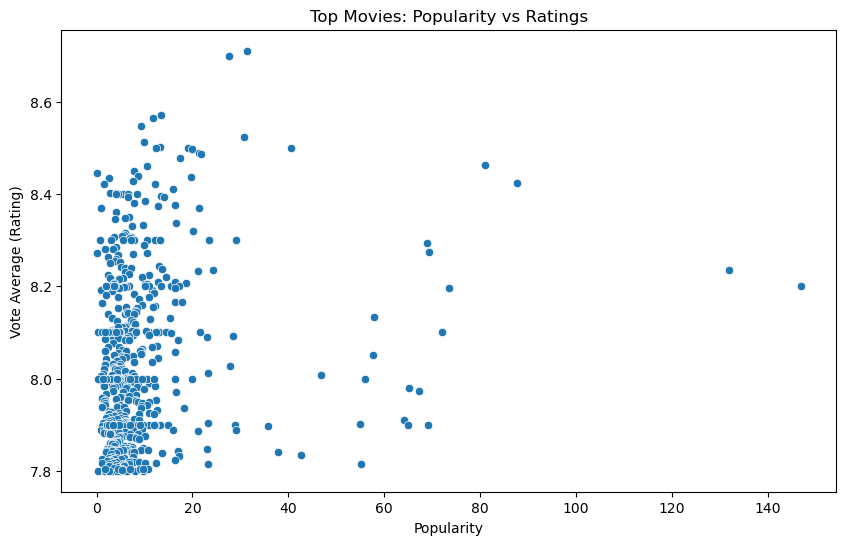

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='popularity', y='vote_average', data=df)
plt.title("Top Movies: Popularity vs Ratings")
plt.xlabel("Popularity")
plt.ylabel("Vote Average (Rating)")
plt.show()

Language-Based Preferences

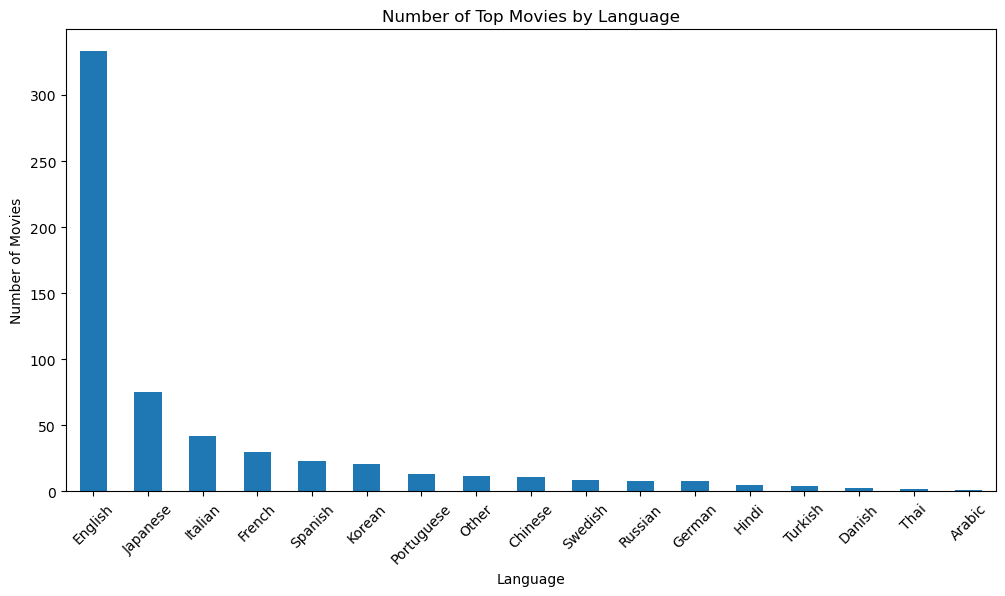

In [27]:
import matplotlib.pyplot as plt

# Language code to full name mapping
language_map = {
    'en': 'English',
    'ja': 'Japanese',
    'fr': 'French',
    'hi': 'Hindi',
    'es': 'Spanish',
    'zh': 'Chinese',
    'ko': 'Korean',
    'de': 'German',
    'it': 'Italian',
    'pt': 'Portuguese',
    'ru': 'Russian',
    'ta': 'Tamil',
    'te': 'Telugu',
    'ur': 'Urdu',
    'ar': 'Arabic',
    'tr': 'Turkish',
    'ml': 'Malayalam',
    'th': 'Thai',
    'id': 'Indonesian',
    'sv': 'Swedish',
    'no': 'Norwegian',
    'da': 'Danish',
    'fi': 'Finnish'
}

# Map codes to full language names
df['original_language_full'] = df['original_language'].map(language_map)

# Replace any unmapped codes with "Other"
df['original_language_full'] = df['original_language_full'].fillna("Other")

# Plot the bar chart
plt.figure(figsize=(12,6))
df['original_language_full'].value_counts().plot(kind='bar', rot=45)
plt.title("Number of Top Movies by Language")
plt.xlabel("Language")
plt.ylabel("Number of Movies")
plt.show()


In [29]:
import pandas as pd

# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract year into a new column
df['year'] = df['release_date'].dt.year

# Drop rows where year is missing
df = df.dropna(subset=['year'])

# Convert year to integer
df['year'] = df['year'].astype(int)

# Preview
df.head()


,id,title,original_title,release_date,vote_average,vote_count,popularity,overview,original_language,original_language_full,year
0,278,The Shawshank Redemption,The Shawshank Redemption,1994-09-23,8.711,29141,31.3451,Imprisoned in the 1940s for the double murder ...,en,English,1994
1,238,The Godfather,The Godfather,1972-03-14,8.700,22013,27.6113,"Spanning the years 1945 to 1955, a chronicle o...",en,English,1972
2,240,The Godfather Part II,The Godfather Part II,1974-12-20,8.571,13301,13.4407,In the continuing saga of the Corleone crime f...,en,English,1974
3,424,Schindler's List,Schindler's List,1993-12-15,8.566,16826,11.7155,The true story of how businessman Oskar Schind...,en,English,1993
4,389,12 Angry Men,12 Angry Men,1957-04-10,8.548,9498,9.3119,The defense and the prosecution have rested an...,en,English,1957


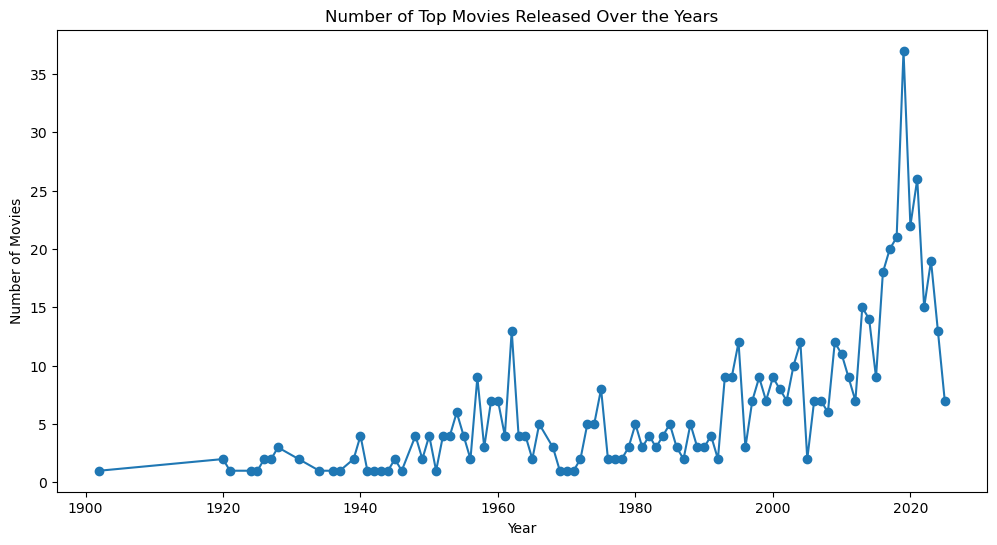

In [47]:
plt.figure(figsize=(12,6))
df.groupby('year').size().plot(kind='line', marker='o')
plt.title("Number of Top Movies Released Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()


Top 10 Most Popular Movies

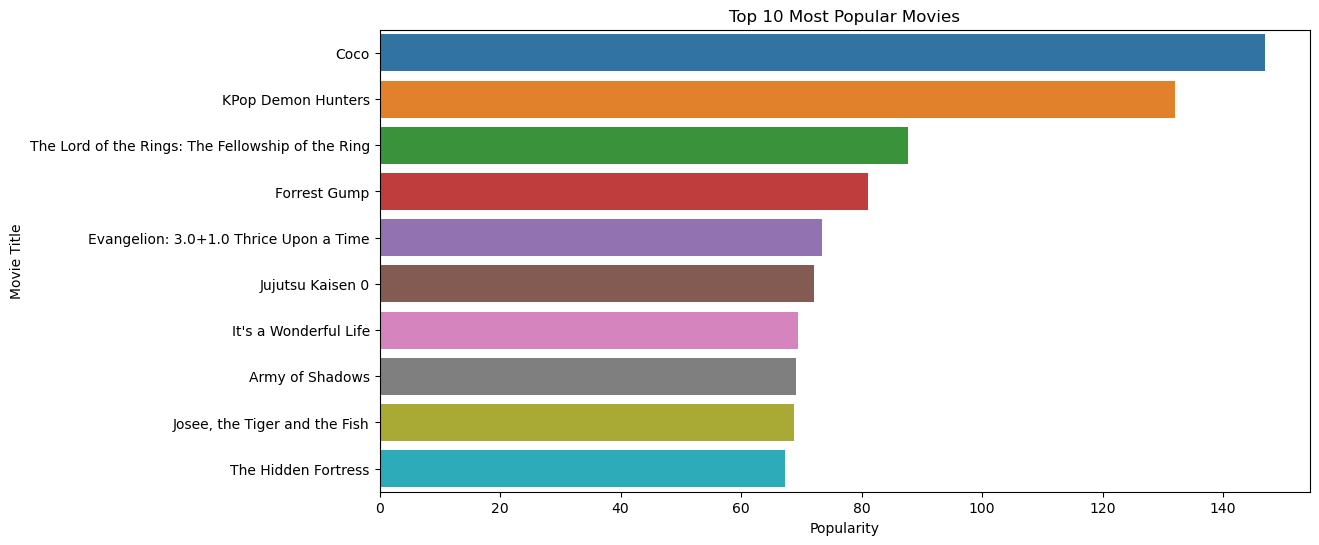

In [39]:
top10_pop = df.sort_values('popularity', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='popularity', y='title', data=top10_pop)
plt.title("Top 10 Most Popular Movies")
plt.xlabel("Popularity")
plt.ylabel("Movie Title")
plt.show()

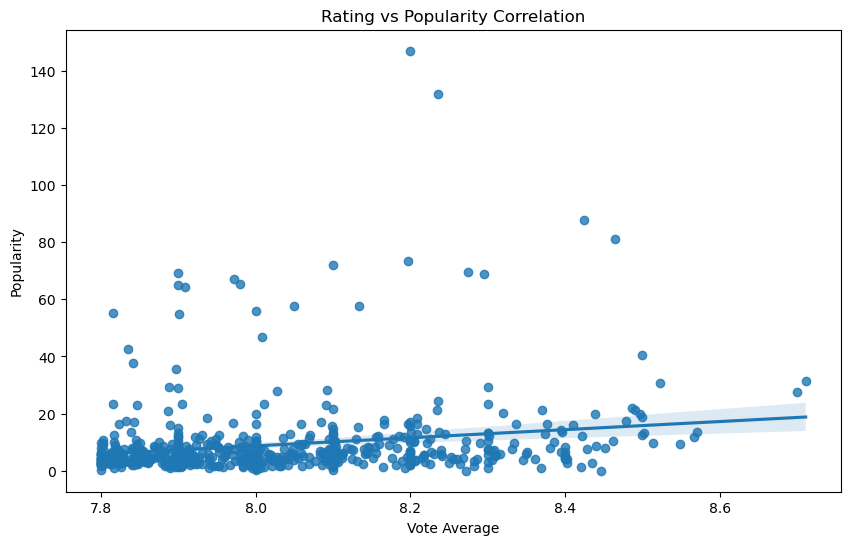

Correlation between vote_average and popularity: 0.19228138138387324


In [40]:
plt.figure(figsize=(10,6))
sns.regplot(x='vote_average', y='popularity', data=df)
plt.title("Rating vs Popularity Correlation")
plt.xlabel("Vote Average")
plt.ylabel("Popularity")
plt.show()

# Print correlation
print("Correlation between vote_average and popularity:", df['vote_average'].corr(df['popularity']))


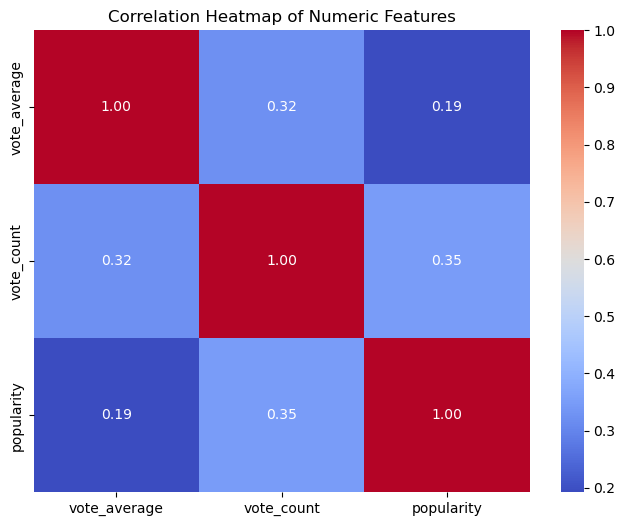

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for correlation
numeric_cols = ['vote_average', 'vote_count', 'popularity']

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


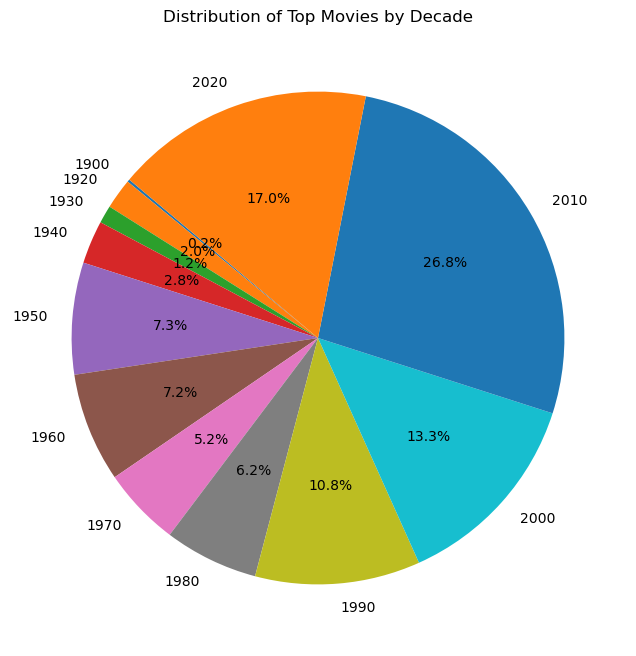

In [42]:
import matplotlib.pyplot as plt

# Create decade column from year
df['decade'] = (df['year'] // 10) * 10

# Count number of movies per decade
decade_counts = df['decade'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(decade_counts, 
        labels=decade_counts.index.astype(int),  # show decades as integers
        autopct='%1.1f%%',                      # show percentage
        startangle=140)                          # rotate start for better view
plt.title("Distribution of Top Movies by Decade")
plt.show()


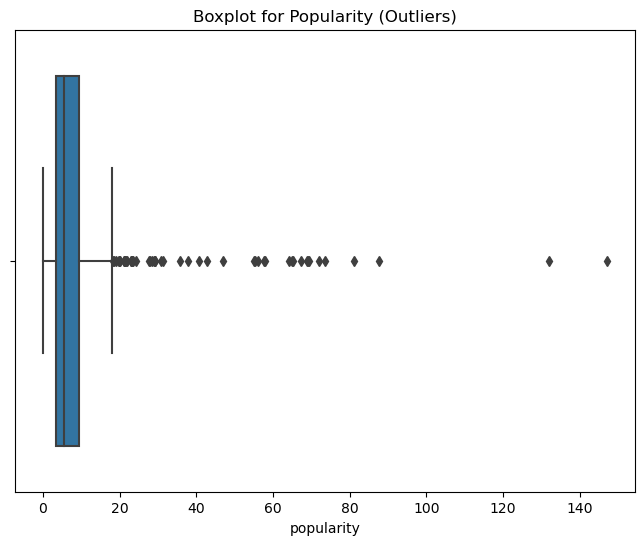

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x=df['popularity'])
plt.title("Boxplot for Popularity (Outliers)")
plt.show()
